### GW tutorial 3: Generation of data and matched filtering

Author: Melissa Lopez

Email: m.lopez@uu.nl

In [4]:
pip install pycbc

In [5]:
%matplotlib inline
from pycbc.catalog import Merger
import pycbc.psd, pycbc.noise
import pylab
import matplotlib.pyplot as plt
import numpy as np
from pycbc.waveform import get_td_waveform
from pycbc.detector import Detector
from pycbc.psd import from_txt
import random

Previously, we have plotted the PSD of different detectors. Some PSDs are from previous runs (O3), while some others are the design sensitivity of future detectors.

The PSD characterizes the noise of the detector, so we can generate detector noise accordingly.

**Exercise 1:** Load the `aligo_O4high.txt` PSD to [generate](https://pycbc.org/pycbc/latest/html/pycbc.noise.html#pycbc.noise.gaussian.noise_from_psd) some Gaussian data.

_Hint:_ Minimum frequency is 10 Hz, sampling rate 4096 Hz and we want 20s of duration

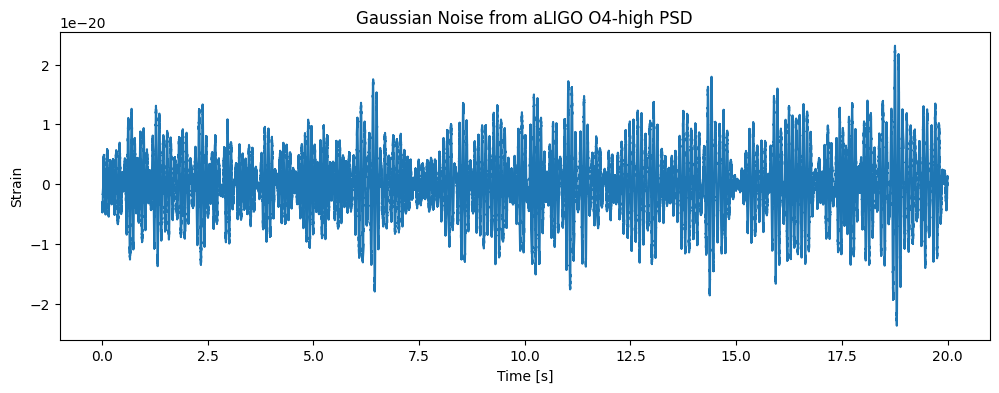

In [6]:
fs = 4096          #sampling rate
T = 20             #duration (seconds)
N = fs * T         #number of samples
f_min = 10.21659   #minimum frequency according to the psd file

#Load PSD from file (download aligo_04.txt and be sure is uploaded in the file section in order to make this code run)
psd = from_txt("/content/aligo_O4high.txt", length=N//2 + 1, delta_f=1.0/T, low_freq_cutoff=f_min)

#Generate Gaussian noise with this PSD
noise = pycbc.noise.noise_from_psd(N, 1.0/fs, psd, seed=None)
#Plot the noise
times = np.arange(N) / fs

plt.figure(figsize=(12,4))
plt.plot(times, noise)
plt.xlabel("Time [s]")
plt.ylabel("Strain")
plt.title("Gaussian Noise from aLIGO O4-high PSD")
plt.show()

As you can see. the generated noise is "coloured" according to the detector noise. Now, we would like to add a simulated gravitational wave signal in our detector noise.

**Exercise 2:** Using [this function](https://pycbc.org/pycbc/latest/html/pycbc.waveform.html#pycbc.waveform.waveform.get_td_waveform) to generate waveforms in time domain, provide the plus and cross polarization of a binary black hole merger of $m_{1} = m_{2} = 50$ at 2000 Mpc. Use the waveform approximant "IMRPhenomD". How does the waveform amplitude compare to the detector noise?

The waveform comes from the source, but it needs to be projected in the detector. [Project](https://pycbc.org/pycbc/latest/html/pycbc.detector.html#pycbc.detector.ground.Detector.project_wave) the waveform on LIGO Livingston (L1) at random sky-location and polarization. You can specify your detector with [this](https://pycbc.org/pycbc/latest/html/pycbc.detector.html#pycbc.detector.ground.Detector) function. How does the waveform change because of this projection?

_Hint:_ Right ascension range is $[0, 2\pi]$, declination is $[-2\pi, 2\pi]$ and polarization is $[0, 2\pi]$.

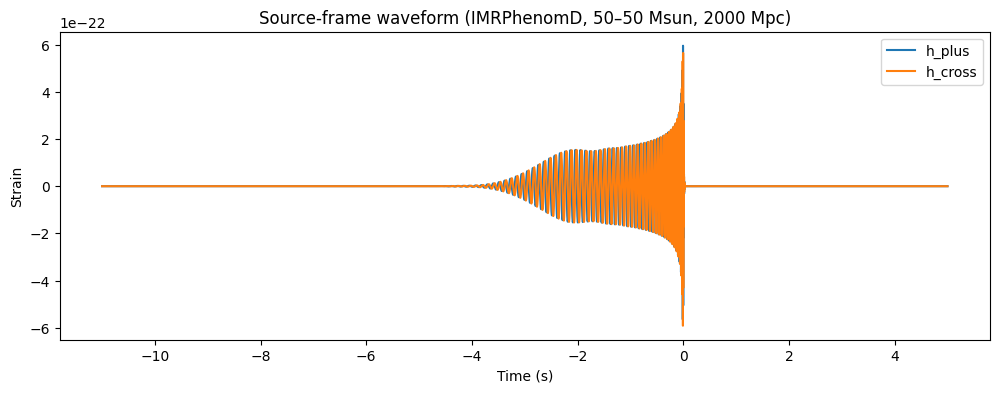

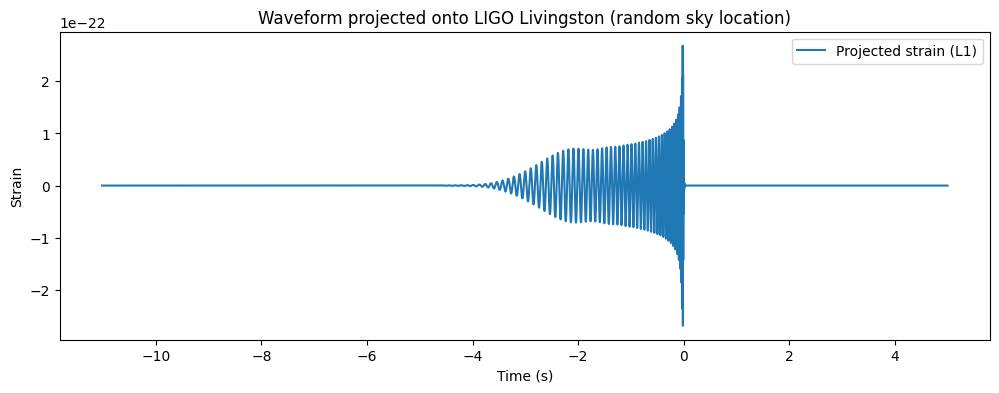

In [13]:
#Waveform parameters for a binary black hole system
m1 = 50
m2 = 50
distance = 2000  #Mpc

#generate time-domain gravitational wave polarizations at the source
hp, hc = get_td_waveform(approximant="IMRPhenomD",
                         mass1=m1,
                         mass2=m2,
                         delta_t=1/4096,
                         f_lower=10,
                         distance=distance)

#plot plus and cross polarizations in the source frame
plt.figure(figsize=(12,4))
plt.plot(hp.sample_times, hp, label="h_plus")
plt.plot(hc.sample_times, hc, label="h_cross")
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.title("Source-frame waveform (IMRPhenomD, 50–50 Msun, 2000 Mpc)")
plt.legend()
plt.show()

#choose a random sky position and polarization for the source
ra = random.uniform(0, 2*np.pi)
dec = random.uniform(-np.pi/2, np.pi/2)
pol = random.uniform(0, 2*np.pi)

#create the LIGO Livingston detector object
L1 = Detector("L1")

#project the source waveform onto the detector response
hL1 = L1.project_wave(hp, hc, ra, dec, pol)

#plot the strain measured by the detector after projection
plt.figure(figsize=(12,4))
plt.plot(hL1.sample_times, hL1, label="Projected strain (L1)")
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.title("Waveform projected onto LIGO Livingston (random sky location)")
plt.legend()
plt.show()


**Exercise 2:** From before our detector noise is 20s long. Add the GW into noise after 5s. We also need to get the first 4s to estimate the PSD in the next excercise. Make an overlaid plot with the total data, the portion of data where the GW is added and the data needed to estimate the PSD.

_Bonus:_ Can you also plot the GW signal?


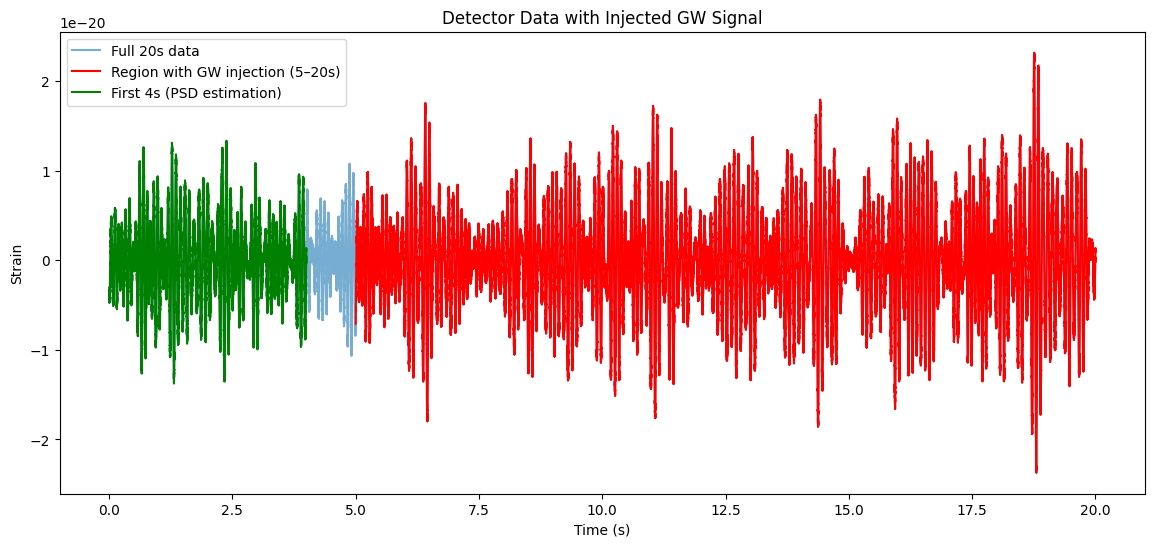

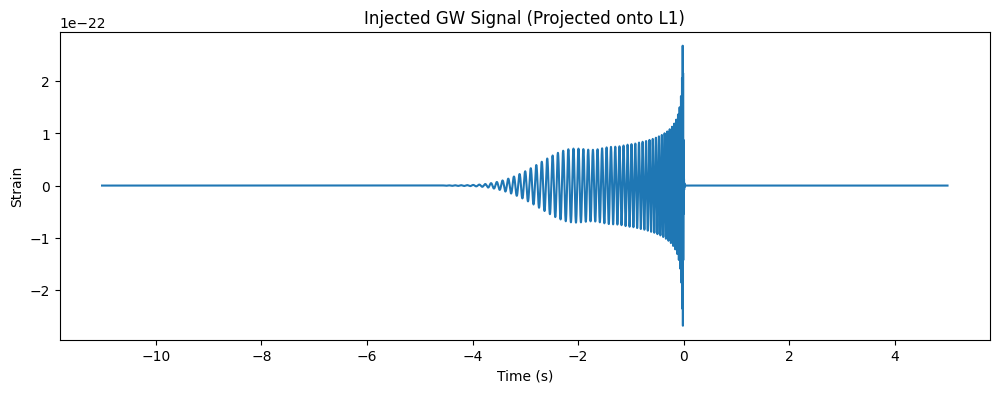

In [14]:
fs = 4096

#convert PyCBC TimeSeries to numpy arrays so indexing/slicing is simple
noise_np = np.array(noise)   # 20 s of noise
h_np = np.array(hL1)         # GW signal
N = len(noise_np)
times = np.arange(N) / fs

#set the injection start time at 5 seconds
start = int(5 * fs)

#make sure the signal fits inside the 20s noise array
max_injection_len = len(noise_np) - start

#truncate the GW if it is longer than the available space after 5s
if len(h_np) > max_injection_len:
    h_np = h_np[:max_injection_len]

#compute the end index of the injected segment
end = start + len(h_np)

#build the final "data" stream by adding the GW into the noise after 5s
data = noise_np.copy()
data[start:end] += h_np

#take the first 4s of data for PSD estimation in the next exercise
psd_data = data[:int(4 * fs)]
psd_times = times[:int(4 * fs)]

#store the time and data window where the GW is injected
inj_times = times[start:end]
inj_data = data[start:end]

#overlay plot showing full data, injection region, and PSD-estimation region
plt.figure(figsize=(14,6))
plt.plot(times, data, label="Full 20s data", alpha=0.6)
plt.plot(inj_times, inj_data, label="Region with GW injection (5–20s)", color="red")
plt.plot(psd_times, psd_data, label="First 4s (PSD estimation)", color="green")
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.title("Detector Data with Injected GW Signal")
plt.legend()
plt.show()

#bonus plot of the injected GW signal alone (projected on L1)
plt.figure(figsize=(12,4))
plt.plot(hL1.sample_times, hL1)
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.title("Injected GW Signal (Projected onto L1)")
plt.show()


**Exercise 3:** In a proper search we do not really have the PSD handy. We want to estimate the PSD with Welch's method (see [here](https://ccrma.stanford.edu/~jos/sasp/Welch_s_Method.html) for details), but we want to use the 4s of the beginning where the GW is not present using [this function](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.welch). Plot the estimated PSD. Note that before we used a dummy whitening, and this one is a bit better.

What is the $\Delta_f$ of the estimated PSD? What is $\Delta_f$ of the data we want to whiten to see the GW signal?

_Hint:_ `seg_stride (int)` is usually half of `seg_len`.


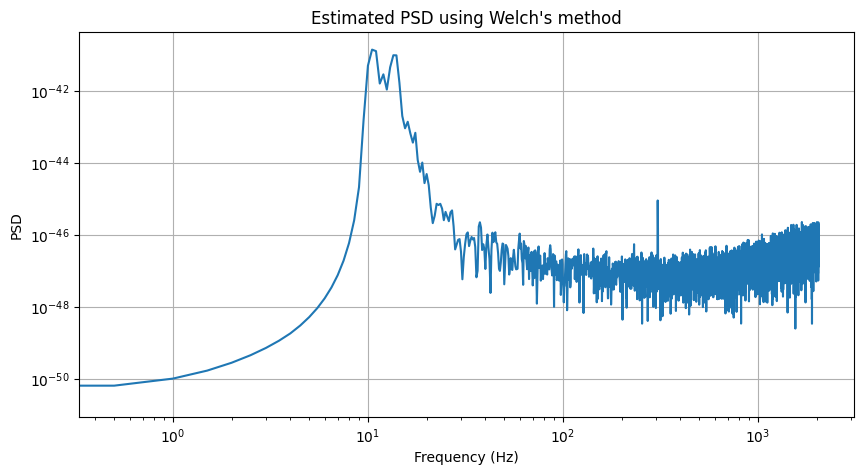

Δf of estimated PSD: 0.5
Δf of 20 s data: 0.05


In [15]:
#Estimate PSD using Welch's method

from pycbc.types import TimeSeries
from pycbc import psd

fs = 4096
delta_t = 1.0 / fs

#turn the first 4 seconds (no GW present) into a PyCBC TimeSeries
psd_ts = TimeSeries(psd_data, delta_t=delta_t)

#choose Welch settings for averaging PSD estimates
seg_len = 2 * fs          #2 s per segment gives df=1/2 Hz inside each FFT
seg_stride = seg_len // 2 #50% overlap is a standard choice to reduce variance

#estimate the PSD from the quiet 4 s stretch using Welch's method
estimated_psd = psd.welch(psd_ts,
                          seg_len=seg_len,
                          seg_stride=seg_stride)

#plot the estimated PSD (one-sided) on log-log axes
plt.figure(figsize=(10,5))
plt.loglog(estimated_psd.sample_frequencies, estimated_psd)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Estimated PSD using Welch's method")
plt.grid(True)
plt.show()

#df of the PSD is the frequency bin spacing of the returned PSD object
df_psd = estimated_psd.delta_f

#df of the 20 s data you want to whiten is set by the full duration (df=1/T)
df_data = 1.0 / 20.0

print("Δf of estimated PSD:", df_psd)
print("Δf of 20 s data:", df_data)


Now that we have the PSD we need to interpolate it to match our data and then limit the filter length of 1 / PSD. After this, we can directly use this PSD to filter the data. Since the data has been highpassed above 12 Hz, and will have low values below this we need to informat the function to not include frequencies below this frequency.

**Exercise 4:** Use the functions [interpolate](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.interpolate) and [inverse_spectrum_truncation](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.inverse_spectrum_truncation) to achieve a proper formatting of the PSD.

_Hint:_ `max_filter_len (int)` is $4 \times$ sampling_rate. Note that the original PSD has a minimum frequency of 12Hz.

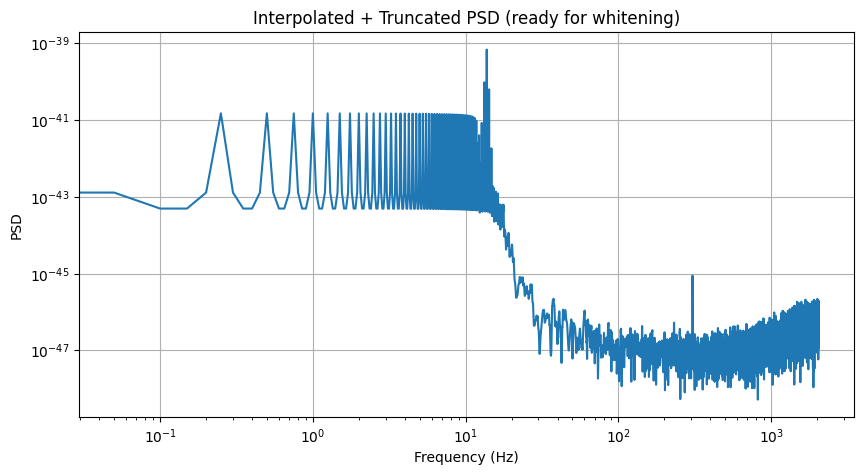

In [16]:
#Interpolate PSD + inverse spectrum truncation

from pycbc.psd import interpolate, inverse_spectrum_truncation

fs = 4096
delta_f_data = 1.0 / 20.0   #df of the 20 s data used later for whitening
low_freq = 12.0             #ignore PSD below 12 Hz because the data is highpassed there
max_filter_len = 4 * fs     #limit the time-domain length of 1/PSD to avoid long ringing

#interpolate the estimated PSD so its frequency bins match the data bins
interp_psd = interpolate(estimated_psd, delta_f_data)

#apply inverse spectrum truncation to control the whitening filter length
trunc_psd = inverse_spectrum_truncation(interp_psd,
                                        max_filter_len=max_filter_len,
                                        low_frequency_cutoff=low_freq)

#plot the final PSD that is properly formatted for filtering/whitening
plt.figure(figsize=(10,5))
plt.loglog(trunc_psd.sample_frequencies, trunc_psd)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Interpolated + Truncated PSD (ready for whitening)")
plt.grid(True)
plt.show()


Now that the PSD is ready, we can whiten the data. Before we used a PyCBC function, but mathematically this is defined as

\begin{equation}
\tilde{d_w}(f) = \tilde{d}(f)/S_{n}^{-1/2}(f)
\end{equation}
where $\tilde{d}$ and $\tilde{d_w}(f)$ are the Fourier transform of the coloured data and whitened data, respectively.

**Exercise 5:** Whiten the data using the interpolated PSD. Crop 5s at the beginning and the end to avoid border effects (_aliasing_) and bandpass it as in the previous exercise. Can you see the GW signal?

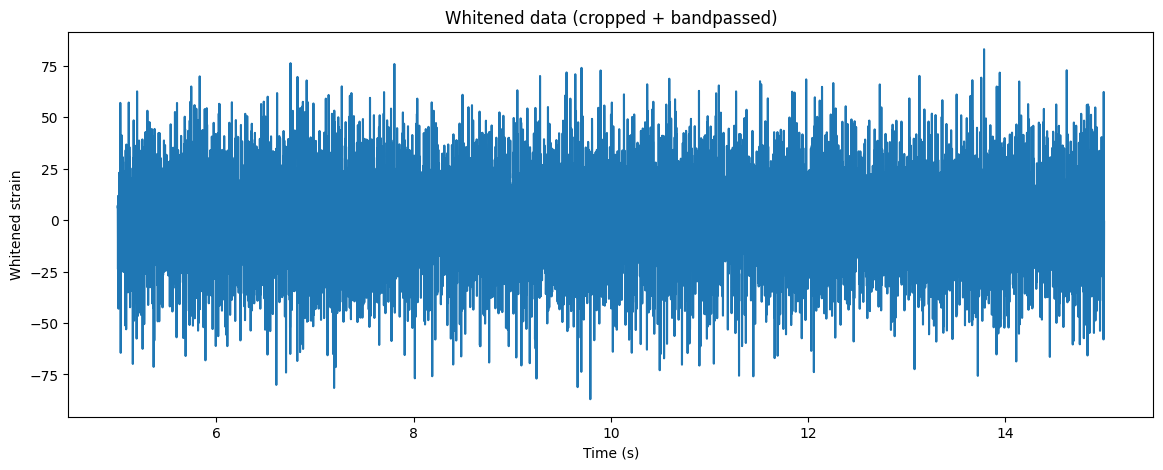

In [17]:
#Exercise 5: Manual whitening of the data

from pycbc.types import TimeSeries
import numpy as np
from pycbc.filter import highpass, lowpass

fs = 4096
delta_t = 1.0 / fs

#convert the full data (noise + possible GW injection) into a PyCBC TimeSeries
data_ts = TimeSeries(data, delta_t=delta_t)

#go to frequency domain because whitening is defined as division by sqrt(PSD) in f-space
data_f = data_ts.to_frequencyseries()

#apply whitening using the PSD formatted in exercise 4
white_f = data_f / trunc_psd**0.5

#return to time domain to look for the signal in time series form
white = white_f.to_timeseries()

#remove 5 s on each side to avoid FFT/filter edge artefacts leaking into the data
white = white.crop(5, 5)

#bandpass to the band where the detector is most sensitive and the BBH signal lives
white = highpass(white, 20.0)
white = lowpass(white, 300.0)

#plot the whitened strain in time domain
plt.figure(figsize=(14,5))
plt.plot(white.sample_times, white)
plt.xlabel("Time (s)")
plt.ylabel("Whitened strain")
plt.title("Whitened data (cropped + bandpassed)")
plt.show()


So far, we buried a GW signal  $h(t)$ in stationary and Gaussian noise $n(t)$ with zero mean, such that $s(t) = h(t) + n(t)$. Given the optimal filter  $K(t)$,

\begin{equation}
\label{eq:filteredsignal}
\hat{s} = \int_{-\infty}^{\infty}  K(t)s(t) dt = \int_{-\infty}^{\infty} \tilde{K}(f)^{*}\tilde{s}(f) df, \quad \text{ where }  \tilde{s}(f) = \int_{-\infty}^{\infty} s(t)e^{-2 \pi i ft}dt
\end{equation}
where $\hat{s}$ is the filtered value of $s(t)$, $^*$ represents the complex conjugate, and $\tilde{\cdot }\ $ the Fourier transform.

The detection statistic that is maximised by the optimal filter $K(t)$  will be the SNR, defined as $\rho = S/N$. $S$ is the expected value of $\hat{s}$ when $h(t) \neq 0$, while $N$ is the squared root of the noise variance when $h(t) =0$. It can be demonstrated that the optimal filter $K(t)$ is the model of the GW signal itself, known as _template_.

The fundamental modelled detection technique is called "matched filtering", since the filter function is chosen to "match" the signal we are looking for. We can write the SNR between an unknown time series $s(t)$ and the template $h_{m}$ as

\begin{equation}
\label{eq:wienerscalar}
\rho =  4 \text{Re} \int_{0}^{\infty} \frac{\tilde{s}^{*}(f)}{S_{n}(f)} \tilde{h_{m}}(f) df.
\end{equation}



**Exercise 6:** Use the [matched_filter](https://pycbc.org/pycbc/latest/html/pycbc.filter.html#pycbc.filter.matchedfilter.matched_filter) function to filter the coloured data with the template. Crop the SNR time series 5s at each side and plot it together with the whitened data. Where is the GW signal? Note that the y-axis of the whitened data is _amplitude_ and the y-axis of the SNR timeseries is _SNR_.

How much is the maximum of the absolute value of the SNR time series? If it is larger than 5 it will generate a "trigger" for further analysis. Will the trigger be generated?

Note that the parameter space of GW signals is vast, so to find these signals, we will need to create a template bank and do this process for thousands of templates. Then, this becomes a high-performance computing problem!

_Hint_: you need to [resize](https://pycbc.org/pycbc/latest/html/pycbc.types.html#pycbc.types.array.Array.resize) the template and use [cyclic_time_shift](https://pycbc.org/pycbc/latest/html/pycbc.types.html#pycbc.types.frequencyseries.FrequencySeries.cyclic_time_shift)

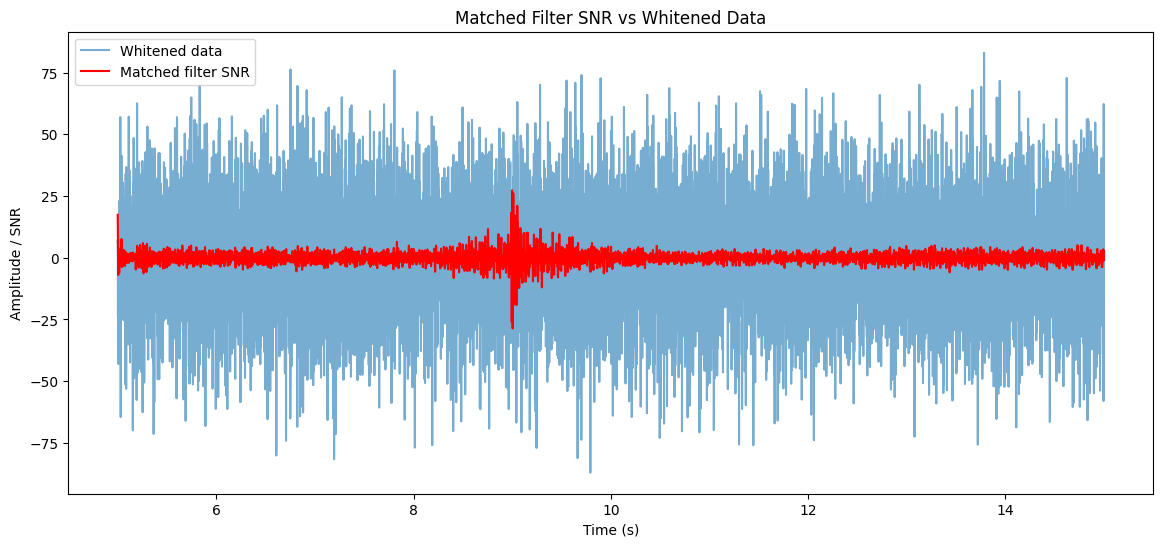

Maximum SNR = 29.86463831919845
A trigger WOULD be generated.


In [18]:
# Matched filtering

from pycbc.filter import matched_filter, resample_to_delta_t, highpass, lowpass
from pycbc.types import TimeSeries
import numpy as np
import matplotlib.pyplot as plt

fs = 4096
delta_t = 1.0 / fs

#use the projected waveform as the template (same detector response as the injection)
target_len = len(data)
template_waveform_data = hL1.data #get numpy array from hL1

#resize the template to match the data length so matched_filter can run
if len(template_waveform_data) < target_len:
    #zero-pad at the end if the template is shorter than the data
    padded_template_data = np.zeros(target_len, dtype=template_waveform_data.dtype)
    padded_template_data[:len(template_waveform_data)] = template_waveform_data
elif len(template_waveform_data) > target_len:
    #truncate if the template is longer than the data
    padded_template_data = template_waveform_data[:target_len]
else:
    #already the right length
    padded_template_data = template_waveform_data

#create the TimeSeries template with the same sampling as the data
template = TimeSeries(padded_template_data, delta_t=delta_t)

#convert the full detector stream to a TimeSeries (noise + injected GW)
data_ts = TimeSeries(data, delta_t=delta_t)

#compute the matched-filter SNR time series using the PSD for weighting
snr = matched_filter(template, data_ts, psd=trunc_psd,
                     low_frequency_cutoff=12.0)

#crop edges because FFT-based filtering produces unreliable boundaries
snr = snr.crop(5, 5)

#plot the whitened data together with the SNR time series (different units on y-axis)
plt.figure(figsize=(14,6))
plt.plot(white.sample_times, white, label="Whitened data", alpha=0.6)
plt.plot(snr.sample_times, snr, label="Matched filter SNR", color="red")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude / SNR")
plt.title("Matched Filter SNR vs Whitened Data")
plt.legend()
plt.show()

#find the maximum absolute SNR and check if it crosses the trigger threshold
max_snr = abs(snr).numpy().max()
print("Maximum SNR =", max_snr)

if max_snr > 5:
    print("A trigger WOULD be generated.")
else:
    print("No trigger would be generated.")


Good job arriving at the end of the tutorial! This was a small peak at GW data analysis that I hope you found interesting.

There is a bonus track exercise if you are bored, but we can also have a chat about some more GW data analysis if you prefer.